In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
latent_dim = 2
batch_size = 128
epochs = 20
num_classes = 10

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
img_input = keras.Input(shape=(28, 28, 1), name="image")
label_input_enc = keras.Input(shape=(num_classes,), name="label_enc")

In [ ]:
x_label = layers.Dense(28 * 28, activation="relu")(label_input_enc)
x_label = layers.Reshape((28, 28, 1))(x_label)

x = layers.Concatenate(axis=-1)([img_input, x_label])

In [ ]:
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

In [ ]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

In [ ]:
encoder = keras.Model(
    [img_input, label_input_enc],
    [z_mean, z_log_var, z],
    name="encoder",
)


In [ ]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_enc           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 784)       │      8,624 │ label_enc[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28, 2) │          0 │ image[0][0],      │
│ (Concatenate)       │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        608 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 429,780 (1.64 MB)

 Trainable params: 429,780 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

latent_input = keras.Input(shape=(latent_dim,), name="z_sampling")
label_input_dec = keras.Input(shape=(num_classes,), name="label_dec")


x = layers.Concatenate(axis=-1)([latent_input, label_input_dec])

x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)  # (14,14,64)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)  # (28,28,32)
x = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)           # (28,28,1)

In [ ]:
decoder = keras.Model(
    [latent_input, label_input_dec],
    x,
    name="decoder",
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_sampling          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_dec           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 12)        │          0 │ z_sampling[0][0], │
│ (Concatenate)       │                   │            │ label_dec[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3136)      │     40,768 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 64)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │     36,928 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │     18,464 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 28, 28, 1) │        289 │ conv2d_transpose… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,449 (376.75 KB)

 Trainable params: 96,449 (376.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class ConditionalVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # data = (images, labels_one_hot)
        x, y = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder([x, y], training=True)
            reconstruction = self.decoder([z, y], training=True)

            # Reconstruction loss: binary crossentropy summed over pixels
            reconstruction_loss = keras.losses.binary_crossentropy(x, reconstruction)
            reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=(1, 2))
            reconstruction_loss = tf.reduce_mean(reconstruction_loss)

            # KL divergence
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
            kl_loss = tf.reduce_mean(kl_loss)

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        z_mean, z_log_var, z = self.encoder([x, y], training=False)
        reconstruction = self.decoder([z, y], training=False)

        reconstruction_loss = keras.losses.binary_crossentropy(x, reconstruction)
        reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=(1, 2))
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)

        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1,
        )
        kl_loss = tf.reduce_mean(kl_loss)

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

cvae = ConditionalVAE(encoder, decoder)
cvae.compile(optimizer=keras.optimizers.Adam())

# Train the model
print("Training the CVAE model...")
history_object = cvae.fit(
    x_train,
    y_train_oh,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test_oh),
)
print("CVAE model training complete.")

Training the CVAE model...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 203ms/step - kl_loss: 3.2972 - loss: 154.5144 - reconstruction_loss: 151.2172 - val_kl_loss: 4.5259 - val_loss: 135.7964 - val_reconstruction_loss: 131.2705
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 205ms/step - kl_loss: 4.4484 - loss: 134.8045 - reconstruction_loss: 130.3561 - val_kl_loss: 4.4627 - val_loss: 133.5445 - val_reconstruction_loss: 129.0818
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - kl_loss: 4.5233 - loss: 133.1917 - reconstruction_loss: 128.6683 - val_kl_loss: 4.5746 - val_loss: 132.2712 - val_reconstruction_loss: 127.6966
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 201ms/step - kl_loss: 4.5576 - loss: 132.2083 - reconstruction_loss: 127.6508 - val_kl_loss: 4.4210 - val_loss: 131.9810 - val_reconstruction_loss: 127.5600
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - kl_loss: 4.5919 - loss: 131.1609 - reconstruction_loss: 126.5690 - val_kl_loss: 4.5788 - val_loss: 131.3459 -

In [ ]:
def generate_digit(model, digit, num_samples=1):
    """
    model      : trained ConditionalVAE instance
    digit      : integer 0–9
    num_samples: how many examples to generate
    """
    if digit < 0 or digit > 9:
        raise ValueError("digit must be in [0, 9]")


    z_random = tf.random.normal(shape=(num_samples, latent_dim))


    labels = np.full((num_samples,), digit, dtype=np.int32)
    labels_onehot = keras.utils.to_categorical(labels, num_classes)


    generated = model.decoder.predict([z_random, labels_onehot])


    for i in range(num_samples):
        plt.figure()
        plt.imshow(generated[i, :, :, 0], cmap="gray")
        plt.axis("off")
        plt.title(f"Generated digit: {digit}")
        plt.show()


Training complete.
Now you can generate digits.
Type a number from 0 to 9, or 'q' to quit.

Enter a digit (0–9) to generate, or 'q' to quit: 54
Please enter a valid digit between 0 and 9.

Enter a digit (0–9) to generate, or 'q' to quit: A
Please enter a valid digit between 0 and 9.

Enter a digit (0–9) to generate, or 'q' to quit: 5
Generating digit 5 ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


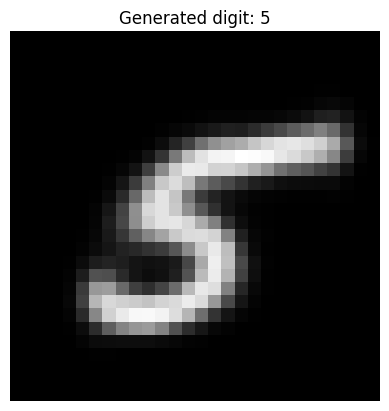

Enter a digit (0–9) to generate, or 'q' to quit: 8
Generating digit 8 ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


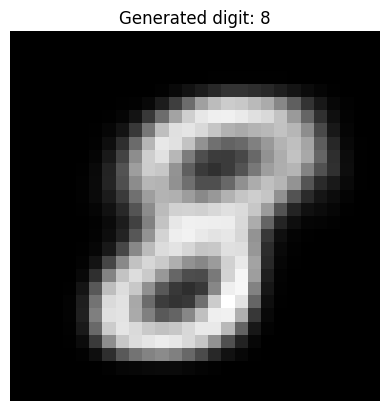

Enter a digit (0–9) to generate, or 'q' to quit: q
Exiting.


In [ ]:
if __name__ == "__main__":
    print("Now you can generate digits.")
    print("Type a number from 0 to 9, or 'q' to quit.\n")

    while True:
        user_input = input("Enter a digit (0–9) to generate, or 'q' to quit: ").strip()
        if user_input.lower() == "q":
            print("Exiting.")
            break

        if not user_input.isdigit() or not (0 <= int(user_input) <= 9):
            print("Please enter a valid digit between 0 and 9.\n")
            continue

        digit = int(user_input)
        print(f"Generating digit {digit} ...")
        generate_digit(cvae, digit, num_samples=1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
decoder.save('/content/drive/MyDrive/cvae_mnist_decoder.keras')
print("Decoder saved to Drive.")

Decoder saved to Drive.
